In [1]:
import pandas as pd
import xarray as xr
import xcdat as xc
import numpy as np
import os
import glob
import re
import cftime
import calendar

/global/homes/j/jungchoi/.conda/envs/pcmdi_metrics/lib/python3.10/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Model information, Target lead time

In [2]:
print("%%%%%%%% start %%%%%%%")
output_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
output_grid = xc.regridder.grid.create_uniform_grid(-88.75, 88.75, 2.5, 0.0, 357.5, 2.5)
output_grid_no = "144x72"

input_dir = "/pscratch/sd/j/jungchoi/OBS"

trend_year_start = 1979
trend_year_end = 2014

trend_years = list(range(trend_year_start, trend_year_end + 1))
print(trend_years)

%%%%%%%% start %%%%%%%
[1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


# Target leadtime average, Horizonal interpolarion for each ensemble members and initializations

In [3]:
def linear_trend(da):
    x = da["time"].dt.year
    y = da.astype("float64")
    
    coef = np.polyfit(x, y, 1)
    return coef[0]  
    
print("%%%%%%%% def linear trend  %%%%%%%")

%%%%%%%% def linear trend  %%%%%%%


In [8]:
#data_name = "ERA5"
#obs_var_name = "t2m"
#out_var_name = "tas"
#obs_var_name = "MSL"
#out_var_name = "psl"

data_name = "GPCP"
obs_var_name = "precip"
out_var_name = "pr"

#data_name = "HadISST"
#obs_var_name = "sic"
#out_var_name = "siconc"

output_grid_no = "144x72"

if out_var_name != "siconc":
    each_ds = []
        
    for year in trend_years:   
        if obs_var_name == "t2m" or obs_var_name == "precip":
            file = os.path.join(input_dir, data_name, f"{obs_var_name}.{year}.{output_grid_no}.nc")
            ds = xr.open_dataset(file)                   
    
        if obs_var_name == "MSL":
            file_list = os.path.join(input_dir, data_name, f"{obs_var_name}.{year}*.nc")
            ds = xr.open_mfdataset(file_list,combine='by_coords')
            #print(ds) 
     
        each_ds.append(ds)    
        ds.close()
    all_ds = xr.concat(each_ds, dim="time")
    print(all_ds.time)

elif out_var_name == "siconc":
    file = os.path.join(input_dir, data_name, "HadISST_ice.nc")
    ds = xr.open_dataset(file) 
    all_ds0 = ds.sel(time=ds.time.dt.year.isin(trend_years))
    all_ds = all_ds0.sortby('latitude')
    output_grid_no = "360x180"
    ds.close()

all_ds = all_ds.rename({obs_var_name: out_var_name})
da = all_ds[f"{out_var_name}"]

years = all_ds.time.dt.year
all_years = years.values.astype(float) 

monthly_slopes = []

for month in range(1, 13):
    da_month = da.where(all_ds.time.dt.month == month, drop=True)
    x = years.where(all_ds.time.dt.month == month, drop=True).values.astype(float)

    def fit_slope(x, y):
        if np.isfinite(y).sum() < 10:
            return np.nan
        return np.polyfit(x, y, deg=1)[0]

    trend = xr.apply_ufunc(
        fit_slope,
        xr.DataArray(x, dims="time"),  # x
        da_month,                      # y
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    monthly_slopes.append(trend)

monthly_trend = xr.concat(monthly_slopes, dim="month")
monthly_trend["month"] = np.arange(1, 13)

if out_var_name == "psl":
    monthly_trend = monthly_trend.regridder.horizontal(f"{out_var_name}", output_grid, tool="regrid2")
    monthly_trend = monthly_trend * 0.01   

if out_var_name == "siconc":
    monthly_trend = monthly_trend * 100.
    
print(monthly_trend)
print(monthly_trend.values)

monthly_trend.name = f"{out_var_name}"
monthly_trend = monthly_trend.to_dataset()
    
# Save to NetCDF for each lead time
output_filename = f"{output_dir}/OBS/{out_var_name}.{output_grid_no}.mon_trend{trend_year_start}-{trend_year_end}.nc"
if os.path.exists(output_filename):
    os.remove(output_filename)
monthly_trend.to_netcdf(output_filename)
print(f"%% OBS monthly trend dataset saved: {output_filename}")

FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/j/jungchoi/OBS/GPCP/precip.1979.144x72.nc'

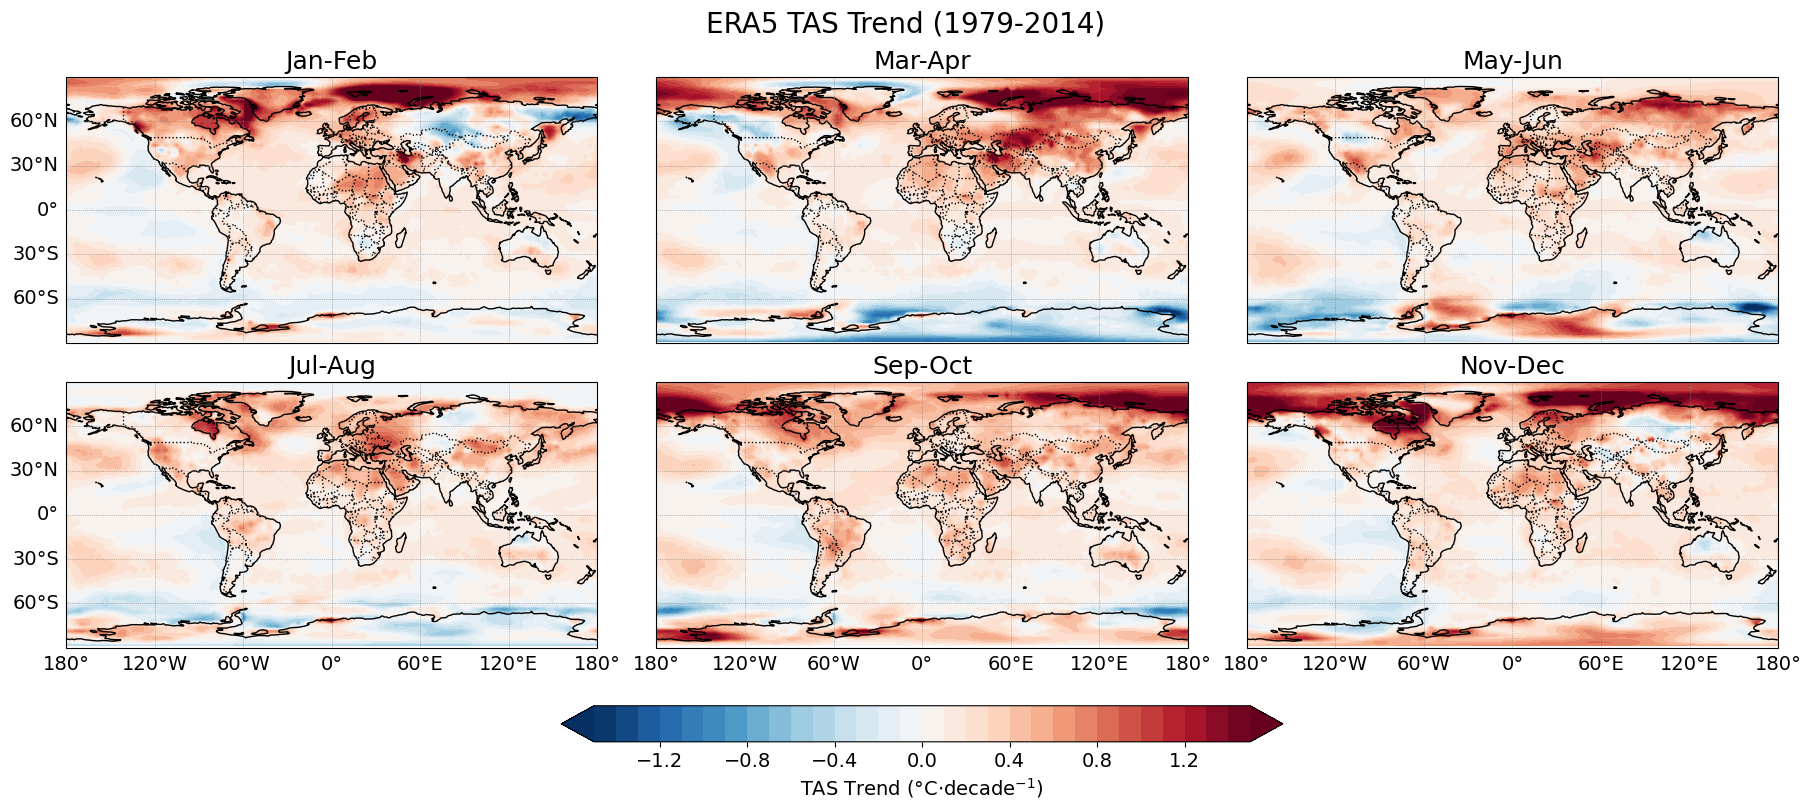

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.ticker import MultipleLocator 
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import xarray as xr
import xcdat as xc
import numpy as np
import os

#print(monthly_trend)
bias = monthly_trend['tas'] * 10.
#bias = monthly_trend['pr'] * 100.
#bias = monthly_trend['siconc'] * 10.

#print(bias)
bimonthly_group = ((bias['month'] - 1) // 2) + 1
bimonthly_means = bias.groupby(bimonthly_group).mean(dim='month')
#print(bimonthly_means)

lons = bimonthly_means.lon
lats = bimonthly_means.lat
#lons = bimonthly_means.longitude
#lats = bimonthly_means.latitude
lon2d, lat2d = np.meshgrid(lons, lats)

from cartopy.util import add_cyclic_point
data = bimonthly_means 
data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lons, axis=-1)
lon2d_cyclic, lat2d_cyclic = np.meshgrid(lon_cyclic, lats)

labels = ['Jan-Feb', 'Mar-Apr', 'May-Jun', 'Jul-Aug', 'Sep-Oct', 'Nov-Dec']

fig, axs = plt.subplots(2, 3, figsize=(18, 8),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        constrained_layout=True)

clevs = np.arange(-1.5, 1.6, 0.1)
#clevs = np.arange(-6, 6.5, 0.5)
#clevs = np.arange(-12, 13, 1)

for i in range(6):
    row = i // 3
    col = i % 3
    ax = axs[row, col]

    # 설정
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # 2개월 평균 데이터
    data_i = data.sel(month=i+1)

    # cyclic 버전 사용
    cf = ax.contourf(lon2d_cyclic, lat2d_cyclic, data_cyclic[i],
                     levels=clevs, cmap='RdBu_r', extend='both',
                     #levels=clevs, cmap='BrBG', extend='both',
                     transform=ccrs.PlateCarree())

    ax.set_title(labels[i], fontsize=18)

    gl = ax.gridlines(draw_labels=True, linestyle=':', linewidth=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = (row == 1)
    gl.left_labels = (col == 0)
    gl.xlocator = MultipleLocator(60)
    gl.ylocator = MultipleLocator(30)
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}

# 공통 colorbar 추가
cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', fraction=0.06, pad=0.05)
cbar.set_label('TAS Trend (°C$\cdot$decade$^{-1}$)', fontsize=14)
#cbar.set_label('PR Trend (mm$\cdot$d$^{-1}$ per 100 yr)', fontsize=14)
#cbar.set_label('SIC Trend (% per 10 yr)', fontsize=14)
cbar.ax.tick_params(labelsize=14)

fig.suptitle("ERA5 TAS Trend (1979-2014)", fontsize=20)
#fig.suptitle("GPCP PR Trend (1979-2014)", fontsize=20)
#fig.suptitle("HadISST_ICE Trend (1979-2014)", fontsize=20)
plt.show()

plt.savefig(f"obs_trend.{out_var_name}.png")
 